# Algorithm defined by the paper for pitch detection

### Step 1: Denoise the audio using the Improved Spectral Subtraction method.

In [209]:
import numpy as np
import scipy.signal
import librosa

# Set the parameters defined in the paper
alpha = 2
beta = 5
HOP_LENGTH = 512 

def improved_spectral_subtraction(noisy_signal, sample_rate):
    # Perform STFT to split the audio into small frequency frames.
    stft_matrix = librosa.stft(noisy_signal, hop_length=HOP_LENGTH)
    # Compute magnitude and phase of the frequency components
    magnitude = np.abs(stft_matrix)
    phase = np.angle(stft_matrix)
    
    # Assume first 0.1 seconds of audio is just background noise and calculate no. of frames and calculate the power spectrum (λ_n(k))
    noise_frames = int(0.1 * sample_rate / HOP_LENGTH) 
    noise_power = np.mean(magnitude[:, :noise_frames] ** alpha, axis=1)
    
    # Applying the mathematical formula from the paper: 
    clean_power = (magnitude ** alpha) - (beta * noise_power[:, np.newaxis]) # Subtracting the noise power into by beta from the noisy signal's power.
    clean_power = np.maximum(clean_power, 0)                                 # If the subtraction results in a negative number, setting it to 0
    clean_magnitude = clean_power ** (1 / alpha)                             # Reversing the alpha power to get the clean magnitude
    
    clean_stft = clean_magnitude * np.exp(1j * phase)               # Recombining the clean magnitude with the original phase to rebuild the audio wave
    clean_signal = librosa.istft(clean_stft, hop_length=HOP_LENGTH) # Converting back to time-domain audio signal
    
    return clean_signal

### Step 2: Using LPC to get error signal
### Step 3: Cepstrum Calculation for error signal
### Step 4: Autocorrelation of the Cepstrum
### Overall: Calculation of pitch for a single small chunk of audio.

In [210]:
lpc_order = 10 # The lpc order is how many past samples it uses to predict next sample. 10 is standard for speech.
def calculate_pitch(frame, sample_rate):
    # skip frames that are silent / nearly silent
    if np.max(np.abs(frame)) < 1e-4: return 0

    # Step 2: Linear Predictive Coding (LPC) Analysis
    # Predicting the coefficients (α_k)
    lpc_coeffs = librosa.lpc(frame, order=lpc_order)
    # Passing speech frame through inverse filter having those coefficients.
    # Removes the vocal tract effect, leaving behind the raw vocal cord pulses (the error).
    prediction_error = scipy.signal.lfilter(lpc_coeffs, [1], frame)
    
    # Step 3: Calculating the Cepstrum
    # Transforming error signal into the frequency domain using Fast Fourier Transform (FFT)
    spectrum = np.fft.fft(prediction_error)
    # Taking natural log of the magnitude. 
    log_spectrum = np.log(np.abs(spectrum) + 1e-8)
    # Taking IFFT of log spectrum to get Cepstrum. 
    cepstrum = np.real(np.fft.ifft(log_spectrum))
    
    # Step 4: Autocorrelation of the Cepstrum
    autocorr = np.correlate(cepstrum, cepstrum, mode='full')
    # Only need the second half of the result corresponding the positive time delays.
    autocorr = autocorr[len(autocorr)//2:]
    
    # Humans speech pitch is usually between 40 Hz and 400 Hz.
    # Converting limit frequencies into "lags" (number of samples of delay).
    min_lag = int(sample_rate / 400) # Maximum frequency -> Minimum delay
    max_lag = int(sample_rate / 40)  # Minimum frequency -> Maximum delay
    
    # If the frame is too short, no pitch detected
    if max_lag >= len(autocorr): return 0    
    # Else, find the lag, that has the highest correlation peak within our human voice range.
    best_lag = np.argmax(autocorr[min_lag:max_lag]) + min_lag 
    # Peak must be strong relative to zero-lag
    if autocorr[0] > 0 and (autocorr[best_lag] / autocorr[0]) < 0.01: return 0
    # Convert the lag (time) back into frequency (Hz)
    pitch_hz = sample_rate / best_lag 
    return pitch_hz

### Correcting Errors

In [211]:
"""
Step 5: Post-processing (Smoothing the pitch line)
Fixes half-frequency, double-frequency, and random errors.
"""

def post_process(pitch_track):
    smoothed_pitch = np.copy(pitch_track)
    c1 = 20 # Max allowed change between neighbour frames
    c2 = 25 # Max allowed change between next-to-neighbour frames
    
    for i in range(2, len(smoothed_pitch) - 1):  # Checking all detected pitches (from the third one)
        fi_minus_1 = smoothed_pitch[i-1]
        fi = smoothed_pitch[i]
        fi_plus_1 = smoothed_pitch[i+1]
        
        if abs((fi / 2) - fi_minus_1) < c1:      # Fix Double Frequency errors
            smoothed_pitch[i] = fi / 2
        elif abs((2 * fi) - fi_minus_1) < c1:    # Fix Half Frequency errors
            smoothed_pitch[i] = 2 * fi 
        else:                                    # Fix stochastic errors
            if abs(fi - fi_minus_1) > c1:                        # if there is sudden jump
                if abs(fi_plus_1 - fi_minus_1) <= c2:                # and if it is corrected immediately after
                    smoothed_pitch[i] = (fi_minus_1 + fi_plus_1) / 2     # change the anomaly to be the AM of neighbours
                else:                                                   
                    smoothed_pitch[i] = fi_minus_1                   # else overwrite anomaly with previous proper value

    return smoothed_pitch

### Splitting into frames and detecting the pitch

In [212]:
def detect_pitch(signal, sample_rate):
    # Denoise
    clean_signal = improved_spectral_subtraction(signal, sample_rate)
    
    # Split the audio into frames
    frame_length_ms = 30
    frame_length_samples = int(sample_rate * (frame_length_ms / 1000))
    raw_pitch_track = []
    # Loop over the audio signal, chunk by chunk
    for i in range(0, len(clean_signal) - frame_length_samples, frame_length_samples):
        frame = clean_signal[i : i + frame_length_samples]           # Extract one frame
        raw_pitch_track.append(calculate_pitch(frame, sample_rate))  # Calculate pitch for each frame frame 
        
    final_pitch_track = post_process(np.array(raw_pitch_track))      # Correct detectable errors
    return final_pitch_track

# A regular pitch detection algorithm to serve as control

In [213]:
def detect_pitch_autocorr(signal, sample_rate):
    frame_length_ms = 30
    frame_length_samples = int(sample_rate * (frame_length_ms / 1000))  # split into frames of 30ms
    pitch_track = []

    for i in range(0, len(signal) - frame_length_samples, frame_length_samples):
        frame = signal[i : i + frame_length_samples]
        if np.max(np.abs(frame)) < 1e-4:
            pitch_track.append(0)
            continue
        autocorr = np.correlate(frame, frame, mode='full')              # uses autocorrelation
        autocorr = autocorr[len(autocorr)//2:]
        min_lag = int(sample_rate / 400)
        max_lag = int(sample_rate / 40)
        if max_lag >= len(autocorr):
            pitch_track.append(0)
            continue
        best_lag = np.argmax(autocorr[min_lag:max_lag]) + min_lag
        pitch_hz = sample_rate / best_lag
        pitch_track.append(pitch_hz) if ((pitch_hz>40) & (pitch_hz<400) | (pitch_hz<0)) else pitch_track.append(0)
    return np.array(pitch_track)

# Comparing the algorithm with a regular pitch detection Algorithm

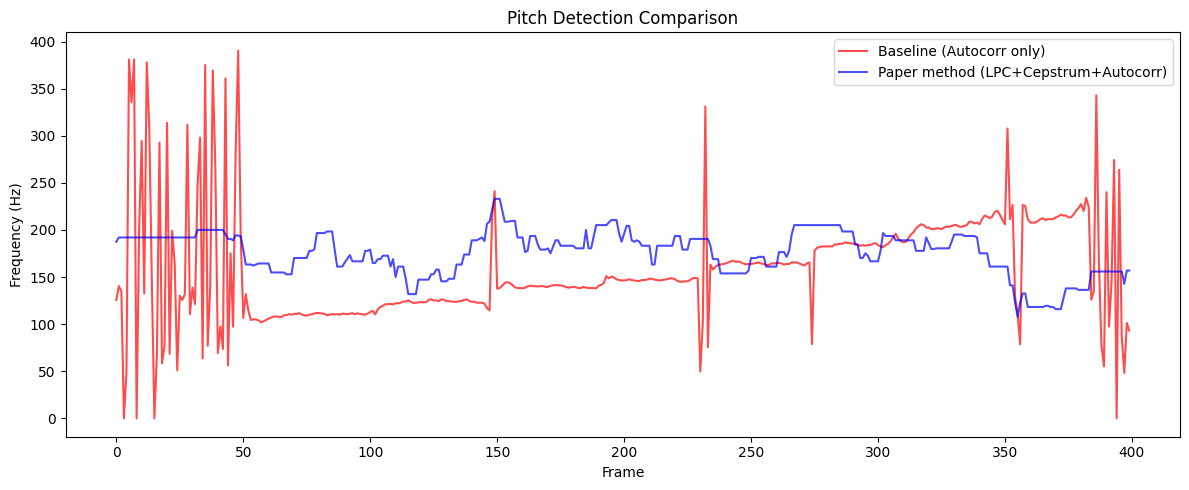

Paper method   — mean: 184.2 Hz, std: 27.5
Baseline method — mean: 167.6 Hz, std: 74.1
Paper voiced frames:    508/509
Baseline voiced frames: 489/509
Paper method distribution:
  Below 120Hz : 15 frames
  120-200Hz   : 341 frames
  200-300Hz   : 152 frames
  Above 300Hz : 0 frames

Baseline distribution:
  Below 120Hz : 118 frames
  120-200Hz   : 239 frames
  200-300Hz   : 91 frames
  Above 300Hz : 41 frames


In [214]:
signal, sr = librosa.load("srgm.wav", sr=None)
pitch_paper   = detect_pitch(signal, sr)           # paper algorithm
pitch_control = detect_pitch_autocorr(signal, sr)  # normal method to serve as control

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(pitch_control[100:500], label='Baseline (Autocorr only)', alpha=0.7, color='red')
plt.plot(pitch_paper[100:500],   label='Paper method (LPC+Cepstrum+Autocorr)', alpha=0.7, color='blue')
plt.xlabel('Frame')
plt.ylabel('Frequency (Hz)')
plt.title('Pitch Detection Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Numeric summary - mean, standar deviation and number of voiced frames detected
voiced_paper   = pitch_paper[pitch_paper > 0]
voiced_control = pitch_control[pitch_control > 0]
print(f"Paper method   — mean: {voiced_paper.mean():.1f} Hz, std: {voiced_paper.std():.1f}")
print(f"Baseline method — mean: {voiced_control.mean():.1f} Hz, std: {voiced_control.std():.1f}")
print(f"Paper voiced frames:    {len(voiced_paper)}/{len(pitch_paper)}")
print(f"Baseline voiced frames: {len(voiced_control)}/{len(pitch_control)}")

# Distribution of Pitches detected
print("Paper method distribution:")
print(f"  Below 120Hz : {np.sum(voiced_paper < 120)} frames")
print(f"  120-200Hz   : {np.sum((voiced_paper >= 120) & (voiced_paper < 200))} frames")
print(f"  200-300Hz   : {np.sum((voiced_paper >= 200) & (voiced_paper < 300))} frames")
print(f"  Above 300Hz : {np.sum(voiced_paper >= 300)} frames")

print("\nBaseline distribution:")
print(f"  Below 120Hz : {np.sum(voiced_control < 120)} frames")
print(f"  120-200Hz   : {np.sum((voiced_control >= 120) & (voiced_control < 200))} frames")
print(f"  200-300Hz   : {np.sum((voiced_control >= 200) & (voiced_control < 300))} frames")
print(f"  Above 300Hz : {np.sum(voiced_control >= 300)} frames")